# 6CS012 - Artificial Intelligence and Machine Learning
## Worksheet 3: Modeling the Neuron – From MCP to Perceptron, Its Learning Algorithm, and Limitations

---

## Section 3: MCP Neurons

### Task 1: Implementation of MCP Neurons

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### MCP Neuron - AND Gate

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operations with MCP Neuron for two inputs.

    Arguments:
        X1 (1D array): An array of binary values.
        X2 (1D array): An array of binary values.
        T  (int/float): Threshold value.

    Returns:
        state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2), "Input arrays must be the same length."

    # Perform element-wise addition of the two input arrays
    summed_inputs = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Create output array
    state_neuron = []

    # Append 1 if the sum >= Threshold, else append 0
    for s in summed_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value for AND gate (both inputs must be 1)

result = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")
print()
print("Truth Table - AND Gate:")
print(f"{'X1':>4} {'X2':>4} {'Output':>8}")
print("-" * 20)
for x1, x2, out in zip(X1, X2, result):
    print(f"{x1:>4} {x2:>4} {out:>8}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]

Truth Table - AND Gate:
  X1   X2   Output
--------------------
   0    0        0
   0    1        0
   1    0        0
   1    1        1


### MCP Neuron - OR Gate

In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.

    Arguments:
        X1 (1D array): An array of binary values.
        X2 (1D array): An array of binary values.
        T  (int/float): Threshold value.

    Returns:
        state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2), "Input arrays must be the same length."

    # Perform element-wise addition of the two input arrays
    summed_inputs = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Create output array
    state_neuron = []

    # Append 1 if the sum >= Threshold, else append 0
    for s in summed_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate (at least one input must be 1)

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")
print()
print("Truth Table - OR Gate:")
print(f"{'X1':>4} {'X2':>4} {'Output':>8}")
print("-" * 20)
for x1, x2, out in zip(X1, X2, result_or):
    print(f"{x1:>4} {x2:>4} {out:>8}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]

Truth Table - OR Gate:
  X1   X2   Output
--------------------
   0    0        0
   0    1        1
   1    0        1
   1    1        1


---
### Question 1: Limitations of MCP Neurons

The MCP (McCulloch-Pitts) Neuron has the following key limitations:

1. Can solve only simple problems
    It works only for linearly separable problems (like AND, OR).
    It cannot solve complex problems like XOR.
2. Uses fixed weights
    The weights are not automatically learned.
    They must be set manually.
3. Binary output only
    Output is either 0 or 1 only.
    Cannot give continuous values.
4. Uses step activation function
    No smooth learning like modern neural networks.
5. No learning ability
    It does not adjust itself from data.
6. Single-layer structure
    Cannot handle multi-layer decision making.

---
### Question 2: Can XOR be Solved Using MCP Neurons?
No — a single MCP neuron cannot solve XOR

Because XOR is not linearly separable.


In [ ]:
# Demonstrating XOR using a network of MCP neurons

def MCP_Neuron(inputs, inhibitory_inputs, T):
    """
    General MCP Neuron.
    inputs: list of excitatory input values (0 or 1)
    inhibitory_inputs: list of inhibitory input values (0 or 1)
    T: threshold
    """
    # If any inhibitory input is active, output is 0
    if any(i == 1 for i in inhibitory_inputs):
        return 0
    g = sum(inputs)
    return 1 if g >= T else 0


def MCP_XOR(X1, X2):
    """
    XOR using a network of MCP neurons.
    XOR(X1, X2) = OR(X1, X2) AND NOT(AND(X1, X2))
    """
    results = []
    for x1, x2 in zip(X1, X2):
        # Neuron 1: OR gate (T=1)
        or_out = MCP_Neuron([x1, x2], [], T=1)
        # Neuron 2: AND gate (T=2)
        and_out = MCP_Neuron([x1, x2], [], T=2)
        # Neuron 3: Final AND — or_out as excitatory, and_out as inhibitory
        xor_out = MCP_Neuron([or_out], [and_out], T=1)
        results.append(xor_out)
    return results


X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
xor_result = MCP_XOR(X1, X2)

print("XOR using network of MCP Neurons:")
print(f"{'X1':>4} {'X2':>4} {'XOR Output':>12}")
print("-" * 24)
for x1, x2, out in zip(X1, X2, xor_result):
    print(f"{x1:>4} {x2:>4} {out:>12}")
print()
print("Expected XOR: [0, 1, 1, 0]")
print("Got:         ", xor_result)

XOR using network of MCP Neurons:
  X1   X2   XOR Output
------------------------
   0    0            0
   0    1            1
   1    0            1
   1    1            0

Expected XOR: [0, 1, 1, 0]
Got:          [0, 1, 1, 0]


---
## Section 4: The Perceptron

### Task 2: Perceptron Algorithm for 0 vs 1 Classification

### Step 1: Generate MNIST 0 and 1 Dataset (since no CSV is provided, we generate it from sklearn)

In [ ]:
from sklearn.datasets import fetch_openml

# Load MNIST dataset
print("Loading MNIST dataset... (this may take a moment)")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_full = mnist.data
y_full = mnist.target.astype(int)

# Filter for digits 0 and 1
mask_01 = (y_full == 0) | (y_full == 1)
X_01 = X_full[mask_01]
y_01 = y_full[mask_01]

print(f"Dataset loaded. Total samples for 0 & 1: {X_01.shape[0]}")

Loading MNIST dataset... (this may take a moment)
Dataset loaded. Total samples for 0 & 1: 14780


### Step 2: Load the Dataset

In [ ]:
# Use the filtered dataset (simulating loading from mnist_0_and_1.csv)
X = X_01
y = y_01

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (14780, 784)
Label vector shape: (14780,)


**Question 1: What does the shape of X represent?**

`X.shape` is `(n_samples, 784)`. The first dimension is the number of images (samples), and `784` is the number of features per image — corresponding to the 28×28 = 784 pixel values of each flattened grayscale MNIST image.

**Question 2: What does the shape of y represent?**

`y.shape` is `(n_samples,)`. It is a 1D array containing the true class label (either `0` or `1`) for each corresponding image in `X`.

### Step 3: Visualize the Dataset

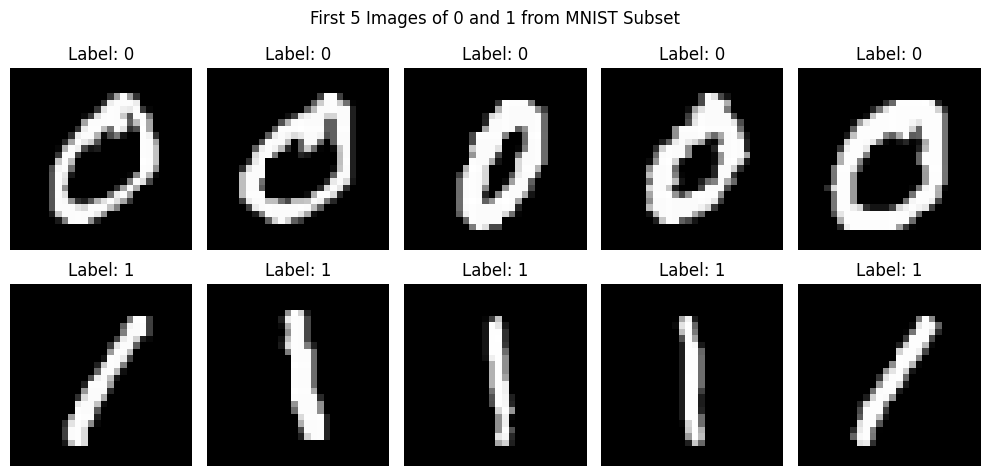

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

### Step 4: Initialize Weights and Bias

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

print(f"Weights shape: {weights.shape}")
print(f"Bias: {bias}")
print(f"Learning rate: {learning_rate}")
print(f"Epochs: {epochs}")

Weights shape: (784,)
Bias: 0
Learning rate: 0.1
Epochs: 100


**Question 3: What does the weights array represent in this context?**

The `weights` array has shape `(784,)` — one weight per pixel of the 28×28 MNIST image. This represennts the importance of each pixel in classification

**Question 4: Why are we initializing the weights to zero? What effect could this have on the training process?**

Weights are initialized to zero because:

1. Starting point for learning
2. Simple initialization method
3. Perceptron updates weights automatically during training

Effect:

Weights change gradually based on errors during training.

### Step 5: Implement the Decision (Activation) Function

In [ ]:
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
        X       : Features (input data) as a numpy array of shape (n_samples, n_features)
        weights : Updated weights after training
        bias    : Updated bias after training

    Returns:
        y_pred_all: The predicted labels for the input data
    """
    # Compute the linear combination z = X·w + b
    predictions = np.dot(X, weights) + bias

    # Apply the step activation function: output 1 if z >= 0, else 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all


# Quick test with initial (zero) weights
initial_preds = decision_function(X[:5], weights, bias)
print("Sample predictions (before training, all should be 1 since z=0 >= 0):", initial_preds)
print("True labels for those samples:", y[:5])

Sample predictions (before training, all should be 1 since z=0 >= 0): [1 1 1 1 1]
True labels for those samples: [0 1 1 1 1]


### Step 6: Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
        X             : Features (input data) as a numpy array of shape (n_samples, n_features)
        y             : Labels (true output) as a numpy array of shape (n_samples,)
        weights       : Initial weights as a numpy array of shape (n_features,)
        bias          : Initial bias value (scalar)
        learning_rate : Learning rate for weight updates (default is 0.1)
        epochs        : Number of iterations to train the model (default is 100)

    Returns:
        weights  : Updated weights after training
        bias     : Updated bias after training
        accuracy : Final training accuracy
    """
    n_samples = X.shape[0]
    accuracy_history = []

    for epoch in range(epochs):
        correct = 0
        convergence_flag = True  # Assume convergence until a mistake is found

        for i in range(n_samples):
            # Step 1: Compute the weighted sum (net input)
            output = np.dot(X[i], weights) + bias

            # Step 2: Apply activation function (step function)
            y_hat = 1 if output >= 0 else 0

            # Step 3: Update weights and bias if prediction is wrong
            if y_hat != y[i]:
                error = y[i] - y_hat
                weights = weights + learning_rate * error * X[i]
                bias = bias + learning_rate * error
                convergence_flag = False
            else:
                correct += 1

        accuracy = correct / n_samples
        accuracy_history.append(accuracy)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{epochs} - Accuracy: {accuracy:.4f}")

        # Early stopping if convergence is reached
        if convergence_flag:
            print(f"\nConverged at epoch {epoch + 1}!")
            break

    return weights, bias, accuracy


print("Training Perceptron on MNIST (0 vs 1)...\n")

Training Perceptron on MNIST (0 vs 1)...



**Question 5: What is the purpose of the `output = np.dot(X[i], weights) + bias` line?**

This line calculates the weighted sum of inputs and bias. It helps the perceptron decide whether output is 0 or 1.

**Question 6: What happens when the prediction is wrong? How are the weights and bias updated?**

When prediction is wrong, the perceptron updates the weights and bias. This helps reduce errors and improve future predictions.


**Question 7: Why is the final accuracy important, and what do you expect it to be?**

Final accuracy shows how well the model works. For digit 0 and 1 classification, accuracy is usually very high.

### Step 7: Train the Perceptron

In [ ]:
# Re-initialize weights and bias before training
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

# Train the perceptron
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)

print("\nThe Final Accuracy is: ", accuracy)

Epoch 10/100 - Accuracy: 0.9995

Converged at epoch 15!

The Final Accuracy is:  1.0


### Step 8: Visualize Misclassified Images

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
print(f"Number of misclassified samples: {len(misclassified_idx)}")

if len(misclassified_idx) > 0:
    n_show = min(10, len(misclassified_idx))
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:n_show]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (0 vs 1)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
Number of misclassified samples: 0
All images were correctly classified!


**Question 8: What does `misclassified_idx` store, and how is it used in this code?**

It stores the index numbers of images that were predicted incorrectly. These images are later shown for checking errors.

**Question 9: How do you interpret the result if the output is "All images were correctly classified!"?**

It means the model predicted all images correctly. So the accuracy is 100%.

---
## Task 3: Perceptron Algorithm for 3 vs 5 Classification

### Step 1: Load and Prepare the 3 vs 5 Dataset

In [ ]:
# Filter MNIST for digits 3 and 5 (re-using the already loaded MNIST data)
mask_35 = (y_full == 3) | (y_full == 5)
X_35 = X_full[mask_35]
y_35_raw = y_full[mask_35]

# Re-encode labels: 3 -> 0, 5 -> 1 (perceptron needs binary labels)
y_35 = np.where(y_35_raw == 3, 0, 1)

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:", y_35.shape)
print(f"Class distribution - Label 3 (encoded 0): {np.sum(y_35 == 0)}, Label 5 (encoded 1): {np.sum(y_35 == 1)}")

Feature matrix shape: (13454, 784)
Label vector shape: (13454,)
Class distribution - Label 3 (encoded 0): 7141, Label 5 (encoded 1): 6313


### Step 2: Visualize the Dataset

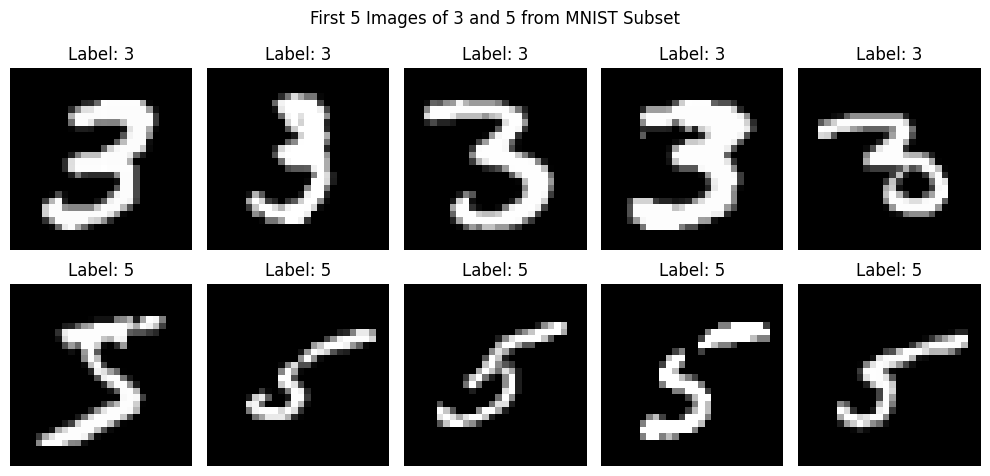

In [ ]:
# Separate images for label 3 and label 5
images_3 = X_35[y_35 == 0]  # encoded 0 -> digit 3
images_5 = X_35[y_35 == 1]  # encoded 1 -> digit 5

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()

### Step 3: Initialize Weights and Bias

In [ ]:
# Initialize weights and bias
weights_35 = np.zeros(X_35.shape[1])  # 784 weights
bias_35 = 0
learning_rate_35 = 0.1
epochs_35 = 100

print(f"Weights shape: {weights_35.shape}")
print(f"Bias: {bias_35}")

Weights shape: (784,)
Bias: 0


### Step 4: Decision Function (same as before)

In [ ]:
# The decision_function defined above is reused here
# Quick test
initial_preds_35 = decision_function(X_35[:5], weights_35, bias_35)
print("Initial predictions (before training):", initial_preds_35)

Initial predictions (before training): [1 1 1 1 1]


### Step 5: Train the Perceptron on 3 vs 5

In [ ]:
print("Training Perceptron on MNIST (3 vs 5)...\n")

weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35, weights_35, bias_35, learning_rate_35, epochs_35
)

print("\nThe Final Accuracy is: ", accuracy_35)

Training Perceptron on MNIST (3 vs 5)...

Epoch 10/100 - Accuracy: 0.9509
Epoch 20/100 - Accuracy: 0.9519
Epoch 30/100 - Accuracy: 0.9550
Epoch 40/100 - Accuracy: 0.9541
Epoch 50/100 - Accuracy: 0.9571
Epoch 60/100 - Accuracy: 0.9572
Epoch 70/100 - Accuracy: 0.9553
Epoch 80/100 - Accuracy: 0.9571
Epoch 90/100 - Accuracy: 0.9590
Epoch 100/100 - Accuracy: 0.9574

The Final Accuracy is:  0.9574104355581983


### Step 6: Evaluate and Visualize Misclassified Images

Final Accuracy (3 vs 5): 0.9516
Number of misclassified samples: 651


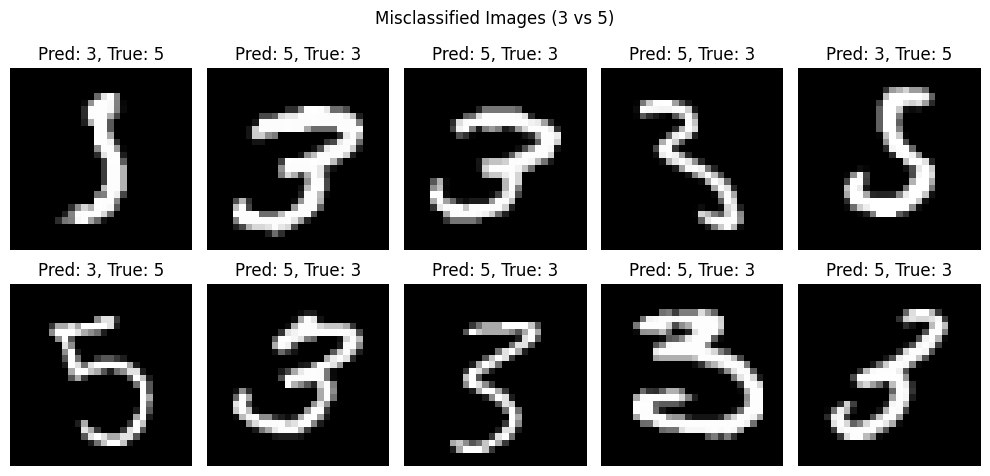

In [ ]:
# Get predictions for all data points
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)

# Calculate final accuracy
final_accuracy_35 = np.mean(y_pred_35 == y_35)
print(f"Final Accuracy (3 vs 5): {final_accuracy_35:.4f}")

# Visualize Misclassified Images
misclassified_idx_35 = np.where(y_pred_35 != y_35)[0]
print(f"Number of misclassified samples: {len(misclassified_idx_35)}")

if len(misclassified_idx_35) > 0:
    # Map encoded labels back to original digit labels for display
    label_map = {0: 3, 1: 5}
    n_show = min(10, len(misclassified_idx_35))
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx_35[:n_show]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        pred_label = label_map[y_pred_35[idx]]
        true_label = label_map[y_35[idx]]
        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

### Visualise Learned Weights

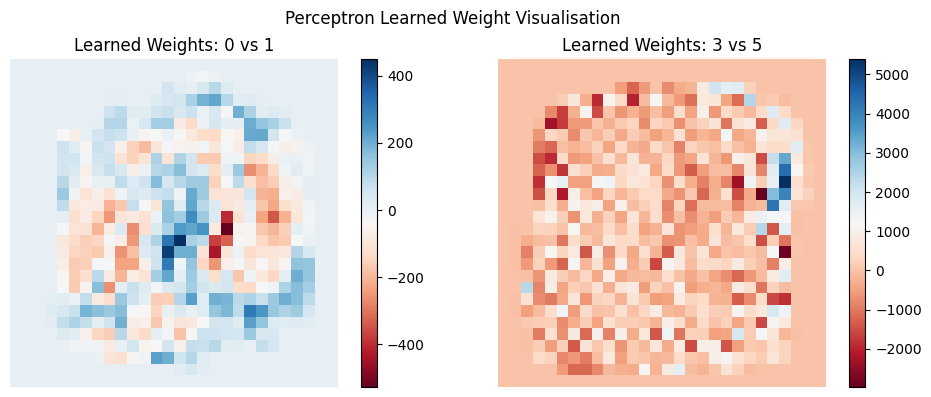

In [ ]:
# Visualise the learned weight vector as a 28x28 image
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(weights.reshape(28, 28), cmap="RdBu", interpolation='nearest')
axes[0].set_title("Learned Weights: 0 vs 1")
axes[0].axis("off")
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(weights_35.reshape(28, 28), cmap="RdBu", interpolation='nearest')
axes[1].set_title("Learned Weights: 3 vs 5")
axes[1].axis("off")
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.suptitle("Perceptron Learned Weight Visualisation")
plt.tight_layout()
plt.show()

### Conclusion: Task 3 – 3 vs 5 Classification

The 3 vs 5 classification task is harder than 0 vs 1 because digits 3 and 5 look similar in shape. Due to this similarity, the perceptron gives lower accuracy and makes more mistakes. This shows that the perceptron cannot handle complex or non-linearly separable data very well. Therefore, more advanced models like multilayer perceptron or CNN are better for such tasks.
